In [ ]:
#importing req. Lib.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('../MIET EDM.csv')
data=df.sample(frac=5, replace=True, random_state=1)
data.head()

,Edad,Edad0,Edad1,Edad2,Genero,Postgrado,Residencia,Interes,Empleo,Empleo0,Empleo1,Modo,Modo1,Modo0,Motivadores,Conocimientos,Atributos
37,Menos de 25,0,0,0,0,0,0,0,Independiente / Emprendedor,1,0,Presencial,0,0,Aumentar mi remuneracion;Adquirir conocimiento...,Innovacion y desarrollo de productos;Liderazgo...,Prestigio académico de la institución;Costo to...
107,Menos de 25,0,0,0,0,0,0,1,Otra,0,0,Semipresencial (una actividad al trimestre),0,1,Avanzar en mi carrera profesional;,Innovacion y desarrollo de productos;Financiam...,Prestigio académico de la institución;Redes de...
12,45 o mas,0,0,1,1,1,1,1,Independiente / Emprendedor,1,0,100% online,1,0,Potenciar mi emprendimiento;Adquirir conocimie...,Propiedad intelectual y patentes;Liderazgo y g...,Costo total del programa;Duracion del programa;
72,25-34,1,0,0,0,0,0,0,Dependiente jornada parcial,0,1,Semipresencial (una actividad al trimestre),0,1,Avanzar en mi carrera profesional;Potenciar mi...,Emprendimiento tecnologico;Innovacion y desarr...,Calidad del cuerpo docente;Costo total del pro...
9,45 o mas,0,0,1,0,0,1,0,Dependiente jornada completa,0,1,100% online,1,0,Avanzar en mi carrera profesional;,Liderazgo y gestión de equipos;,Prestigio académico de la institución;Costo to...


## **Wordcloud for positive reasons**

In [ ]:
from wordcloud import WordCloud,STOPWORDS
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
spanish_sw = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


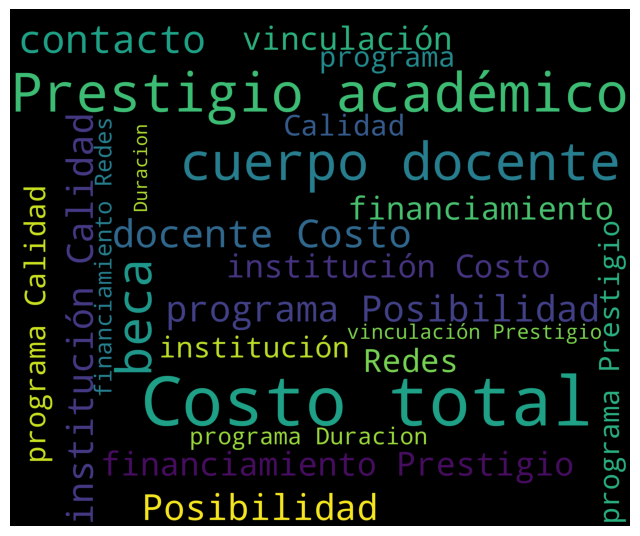

In [ ]:
new_df=data[data['Interes']==0]
words = ' '.join(new_df['Motivadores'])
words = ' '.join(new_df['Conocimientos'])
words = ' '.join(new_df['Atributos'])
cleaned_word = " ".join([word for word in words.split()
                            if 'http' not in word
                                and not word.startswith('@')
                                and word != 'RT'
                            ])
wordcloud = WordCloud(stopwords=spanish_sw,
                      background_color='black',
                      width=3000,
                      height=2500
                     ).generate(cleaned_word)
plt.figure(1,figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

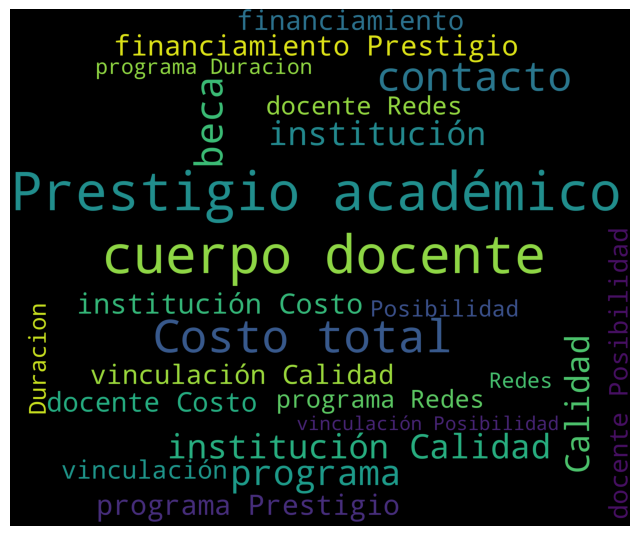

In [ ]:
new_df=data[data['Interes']==1]
words = ' '.join(new_df['Motivadores'])
words = ' '.join(new_df['Conocimientos'])
words = ' '.join(new_df['Atributos'])
cleaned_word = " ".join([word for word in words.split()
                            if 'http' not in word
                                and not word.startswith('@')
                                and word != 'RT'
                            ])
wordcloud = WordCloud(stopwords=spanish_sw,
                      background_color='black',
                      width=3000,
                      height=2500
                     ).generate(cleaned_word)
plt.figure(1,figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

Wordcloud for Negative sentiments of tweets

## **Preprocessing the tweet text data**

Now, we will clean the tweet text data and apply classification algorithms on it

In [ ]:
def tweet_to_words(tweet):
    letters_only = re.sub(r'#([A-Za-z_À-ÿ]+)', " ",tweet)
    words = letters_only.lower().split()
    stops = set(stopwords.words("spanish"))
    meaningful_words = [w for w in words if not w in stops]
    return( " ".join( meaningful_words ))

In [ ]:
nltk.download('stopwords')
data['Total'] = words
data['clean_tweet']=data['Atributos'].apply(lambda x: tweet_to_words(x))
data['clean_tweet'] = data['clean_tweet'].str.replace(r';', ' ', regex=True)
data['clean_tweet'].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,clean_tweet
37,prestigio académico institución costo total pr...
107,prestigio académico institución redes contacto...
12,costo total programa duracion programa
72,calidad cuerpo docente costo total programa du...
9,prestigio académico institución costo total pr...


# **Vectorization**

In [ ]:
x = data.clean_tweet
y = data.Interes

print(len(x), len(y))

550 550


### The data is split in the standard 80,20 ratio

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)
print(len(x_train), len(y_train))
print(len(x_test), len(y_test))

412 412
138 138


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# instantiate the vectorizer
vect = CountVectorizer()
vect.fit(x_train)

CountVectorizer()

In [ ]:
vect_tunned = CountVectorizer(ngram_range=(1,3), min_df=0.1, max_df=0.7, max_features=20)
vect_tunned.fit(x_train)

CountVectorizer(max_df=0.7, max_features=20, min_df=0.1, ngram_range=(1, 3))

In [ ]:
# Use the trained to create a document-term matrix from train and test sets
x_train_dtm = vect_tunned.transform(x_train)
x_test_dtm = vect_tunned.transform(x_test)

# **Model Building (Support Vector Machine)**

In [ ]:
#training SVM model with linear kernel
#Support Vector Classification-wrapper around SVM
from sklearn.svm import SVC
model = SVC(kernel='linear', random_state = 10)
model.fit(x_train_dtm, y_train)
#predicting output for test data
pred = model.predict(x_test_dtm)

In [ ]:
#accuracy score
accuracy_score(y_test,pred)

0.5869565217391305

In [ ]:
#building confusion matrix
cm = confusion_matrix(y_test, pred)
cm

array([[55, 22],
       [35, 26]])

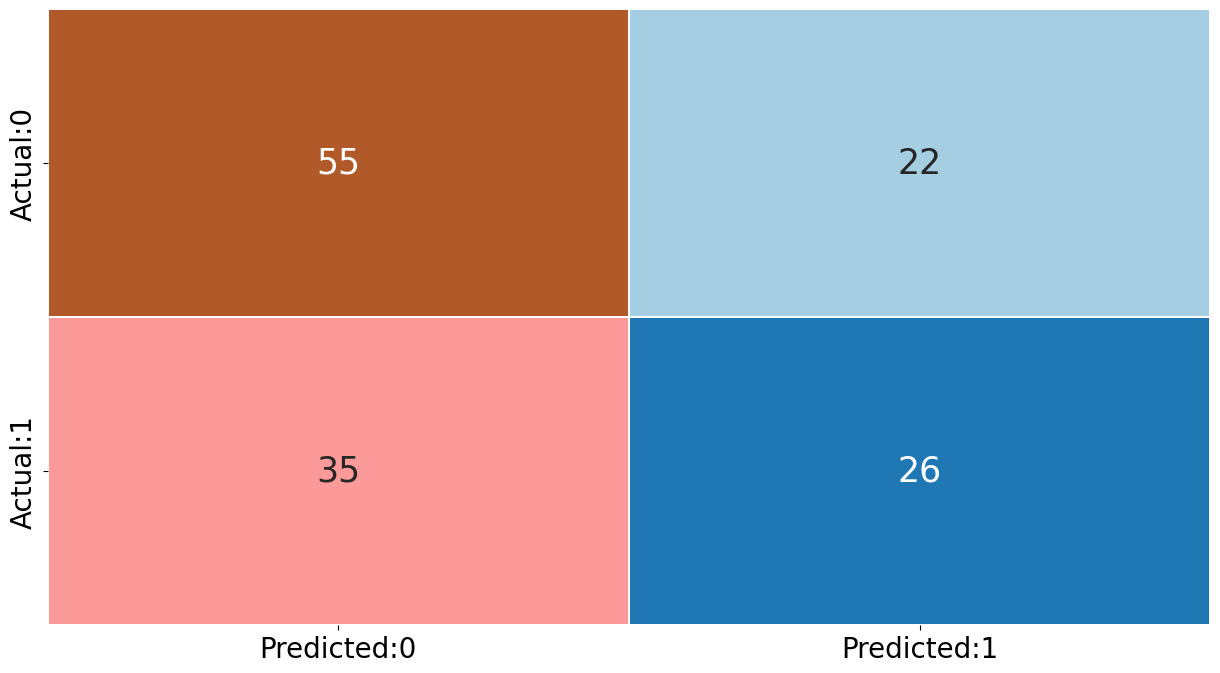

In [ ]:
#defining the size of the canvas
plt.rcParams['figure.figsize'] = [15,8]
#confusion matrix to DataFrame
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1',], index = ['Actual:0','Actual:1',])
#plotting the confusion matrix
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Paired', cbar = False,linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()


In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.61      0.71      0.66        77
           1       0.54      0.43      0.48        61

    accuracy                           0.59       138
   macro avg       0.58      0.57      0.57       138
weighted avg       0.58      0.59      0.58       138



In [ ]:
dfout = pd.DataFrame(vect_tunned.get_feature_names_out())
dfout['feature_coef'] = pd.DataFrame(model.coef_[0].toarray()).T
dfout.sort_values(by='feature_coef', ascending=False, inplace=True)
dfout.head(100)

,0,feature_coef
0,académico,0.111094
1,académico institución,0.111094
16,prestigio académico institución,0.111094
11,institución,0.111094
14,prestigio,0.111094
15,prestigio académico,0.111094
3,calidad cuerpo,0.111083
2,calidad,0.111083
10,docente,0.111083
4,calidad cuerpo docente,0.111083


# **Thank You**